<h1 style="color:#C39BD3; border-bottom: 3px solid #C39BD3; padding-bottom: 8px;">
AI & ML Course with BinX — Week 2 — Day 4 — EDA Part 1: Distributions & Outliers
</h1>

## <span style="color:#F78BA0">4.1  What EDA Is and Why It Comes First</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;"> Befor jumping into any model, I need to actually understand my data first - what it looks like, how it's distributed,and where the problems are hiding. Skipping this step is probably the biggest reason ML projects fail, because a model is only as good as how well you understand what you're feeding it. </blockquote>


## <span style="color:#F78BA0">4.2  Seaborn: Statistical Visualization</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;"> Seaborn is basically Matplotlib but leveld up for statistics - same engine underneath, but it savesme a ton of code for things like histograms and box plots, and it plugs straight into a Pandas DataFrame without extra steps. That's why I'm using it from here on gor exploring the data.   </blockquote>


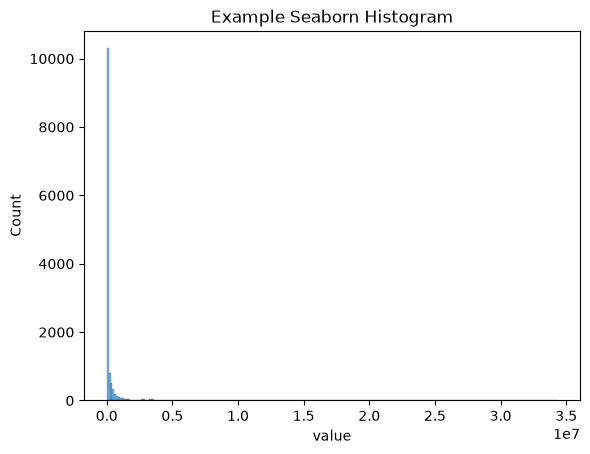

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("data.csv")

sns.histplot(data=df, x="value", color="#42A5F5")

plt.title("Example Seaborn Histogram")
plt.show()

## <span style="color:#F78BA0">4.3 Univariate Analysis</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

**Univariate Analysis** focuses on analyzing **one variable at a time** to understand its distribution and characteristics.

It helps answer questions such as:

- 📈 How are the values distributed?
- 📦 Are there any outliers?
- 📊 How often does each category appear?
- 📉 Is the distribution symmetric or skewed?

</blockquote>

## <span style="color:#7E57C2">📊 Common Univariate Plots</span>

| Plot | Seaborn Function | What It Reveals |
|:-----|:-----------------|:----------------|
| 📈 Histogram | `sns.histplot()` | Shows the distribution of a numeric variable |
| 📦 Box Plot | `sns.boxplot()` | Shows the median, quartiles, and potential outliers |
| 📊 Count Plot | `sns.countplot()` | Shows the frequency of each category |
| 📉 KDE Plot | `sns.kdeplot()` | Shows a smooth estimate of the distribution |



## <span style="color:#42A5F5">💻 Histogram Example</span>

<blockquote style="border-left: 3px solid #2196F3; padding-left: 12px; margin-left: 0;">

A histogram displays how numeric values are distributed across different ranges.

It is useful for identifying:

- Distribution shape
- Skewness
- Gaps
- Peaks

</blockquote>

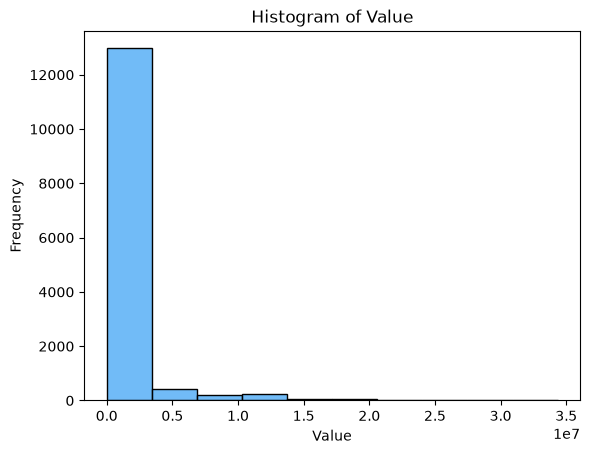

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv")

sns.histplot(data=df, x="value",color="#42A5F5", bins=10)

plt.title("Histogram of Value")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.show()

## <span style="color:#66BB6A">✅ Histogram Explanation</span>

<blockquote style="border-left: 3px solid #4CAF50; padding-left: 12px; margin-left: 0;">

The histogram groups numeric values into bins and shows how many observations fall into each range.

A histogram helps us quickly understand the overall distribution of a variable.

</blockquote>

## <span style="color:#42A5F5">💻 Box Plot Example</span>

<blockquote style="border-left: 3px solid #2196F3; padding-left: 12px; margin-left: 0;">

A box plot summarizes the distribution using:

- Median
- Quartiles
- Minimum and maximum values
- Potential outliers

</blockquote>

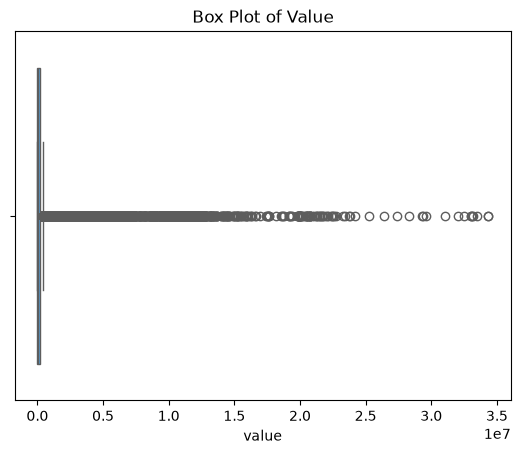

In [12]:
sns.boxplot(data=df, x="value",color="#42A5F5")

plt.title("Box Plot of Value")

plt.show()

## <span style="color:#66BB6A">✅ Box Plot Explanation</span>

<blockquote style="border-left: 3px solid #4CAF50; padding-left: 12px; margin-left: 0;">

The line inside the box represents the **median**.

The box shows the **middle 50%** of the data.

Points outside the whiskers may be potential outliers.

</blockquote>

## <span style="color:#42A5F5">💻 Count Plot Example</span>

<blockquote style="border-left: 3px solid #2196F3; padding-left: 12px; margin-left: 0;">

A count plot displays the frequency of each category in a categorical variable.

It helps identify:

- 📊 Most common categories
- ⚖️ Class imbalance
- 📈 Distribution of categorical data

</blockquote>

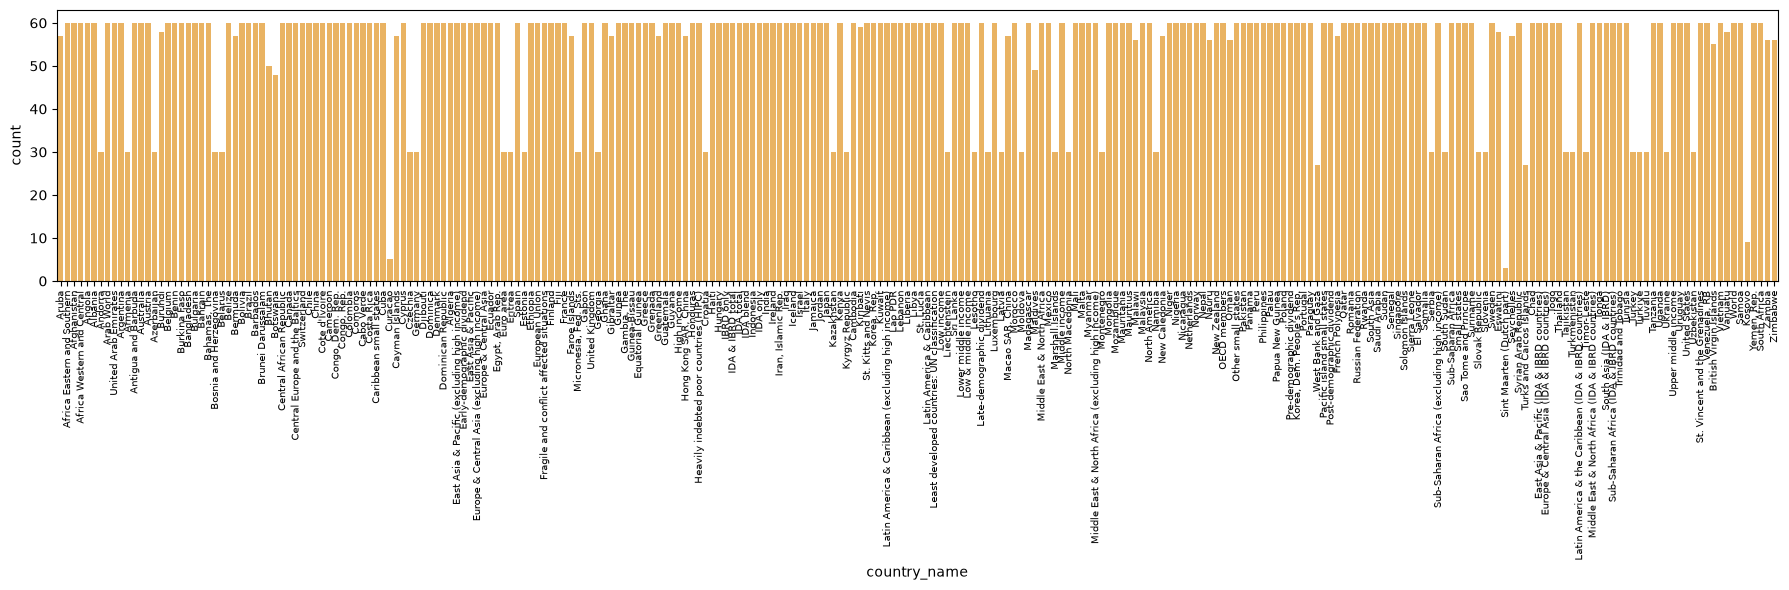

In [22]:
plt.figure(figsize=(18,6))

sns.countplot(
    data=df,
    x="country_name",
    color="#FFB74D"
)

plt.xticks(rotation=90, fontsize=7)

plt.tight_layout()

plt.show()

## <span style="color:#66BB6A">✅ Count Plot Explanation</span>

<blockquote style="border-left: 3px solid #4CAF50; padding-left: 12px; margin-left: 0;">

The count plot shows the frequency of each category.

In this dataset, each country appears only once, so all bars have nearly the same height.

For datasets with repeated categories, this plot helps identify the most common categories and detect class imbalance.

</blockquote>

## <span style="color:#42A5F5">💻 KDE Plot Example</span>

<blockquote style="border-left: 3px solid #2196F3; padding-left: 12px; margin-left: 0;">

A **KDE (Kernel Density Estimation)** plot shows a smooth estimate of the distribution of a numeric variable.

It helps us understand:

- 📈 The shape of the distribution
- 🎯 Where values are concentrated
- ↔️ Possible skewness in the data

</blockquote>

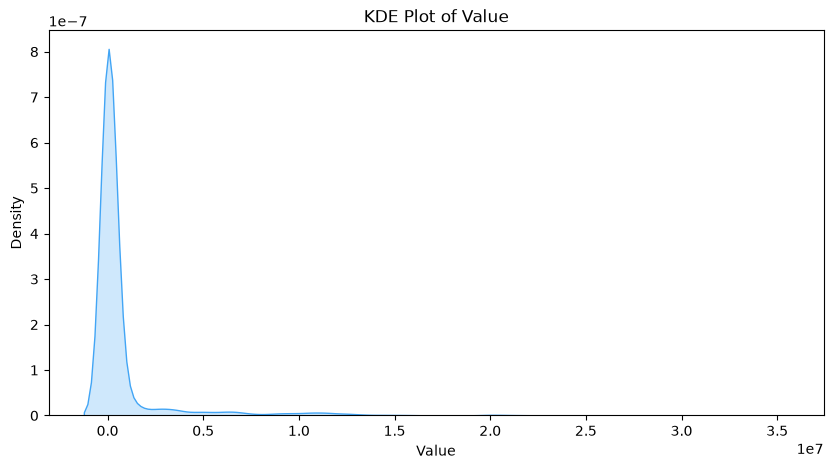

In [27]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    data=df,
    x="value",
    fill=True,
    color="#42A5F5"
)

plt.title("KDE Plot of Value")
plt.xlabel("Value")
plt.ylabel("Density")

plt.show()

## <span style="color:#66BB6A">✅ KDE Plot Explanation</span>

<blockquote style="border-left: 3px solid #4CAF50; padding-left: 12px; margin-left: 0;">

The KDE plot provides a smooth representation of the data distribution.

The highest points of the curve indicate where values are most concentrated.

It helps identify the overall shape of the distribution and compare patterns more easily than individual data points.

</blockquote>

## <span style="color:#F78BA0">4.4 Outlier Detection with the IQR Method</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

An **outlier** is a value that is significantly different from the rest of the data.

Outliers can represent:

- ✅ A real rare event
- ❌ A data entry mistake
- ⚠️ An unusual but important observation

Finding outliers helps us understand our data before building Machine Learning models.

</blockquote>

## <span style="color:#7E57C2">📐 Understanding the IQR Method</span>

<blockquote style="border-left: 3px solid #7E57C2; padding-left: 12px; margin-left: 0;">

The **Interquartile Range (IQR)** measures the spread of the middle 50% of the data.

The formulas:

- **Q1** → 25th percentile
- **Q2** → Median (50th percentile)
- **Q3** → 75th percentile

The IQR is calculated as:

**IQR = Q3 - Q1**

A value is considered a potential outlier if:

- Below: **Q1 - 1.5 × IQR**
- Above: **Q3 + 1.5 × IQR**

</blockquote>

In [28]:
Q1 = df["value"].quantile(0.25)
Q3 = df["value"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["value"] < lower_bound) |
    (df["value"] > upper_bound)
]

outliers

,country_code,country_name,year,value
100,AFE,Africa Eastern and Southern,2003,426379.996829
101,AFE,Africa Eastern and Southern,2004,457599.991269
102,AFE,Africa Eastern and Southern,2005,458459.994629
103,AFE,Africa Eastern and Southern,2006,465440.008163
104,AFE,Africa Eastern and Southern,2007,486179.996997
...,...,...,...,...
13836,ZAF,South Africa,2015,424809.997559
13837,ZAF,South Africa,2016,425140.014648
13838,ZAF,South Africa,2017,435649.993896
13839,ZAF,South Africa,2018,434350.006104


## <span style="color:#66BB6A">✅ IQR Calculation Explanation</span>

<blockquote style="border-left: 3px solid #4CAF50; padding-left: 12px; margin-left: 0;">

The IQR method identifies values that are far away from the normal range.

First, we calculate Q1 and Q3 to understand the spread of the data.

Then, we define lower and upper boundaries. Any value outside these boundaries is marked as a potential outlier.

</blockquote>

In [29]:
print("\033[91mNumber of outliers:\033[0m", len(outliers))

Number of outliers: 2425


## <span style="color:#66BB6A">💡 Important Note</span>

<blockquote style="border-left: 3px solid #4CAF50; padding-left: 12px; margin-left: 0;">

An outlier is **a question, not a verdict**.

We should investigate whether the value is a real observation or an error before deciding to keep, modify, or remove it.

Outliers should never be deleted silently.

</blockquote>

# <span style="color:#C39BD3">🧪 Hands-On Lab: Univariate EDA on a Real Dataset</span>

<blockquote style="border-left: 3px solid #C39BD3; padding-left: 12px; margin-left: 0;">

In this lab, we will apply Univariate Exploratory Data Analysis (EDA) techniques on a real dataset.

The goal is to understand the dataset's distributions, detect possible outliers, and discover patterns before applying Machine Learning models.

</blockquote>

## <span style="color:#F78BA0">Step 1 — Explore Numeric Variables</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

First, we load the dataset and identify numeric columns.

Histograms help us understand the distribution of each numeric variable.

</blockquote>

In [30]:
numeric_columns = df.select_dtypes(include="number").columns

print("\033[94mNumeric Columns:\033[0m")
print(numeric_columns)

Numeric Columns:
Index(['year', 'value'], dtype='str')


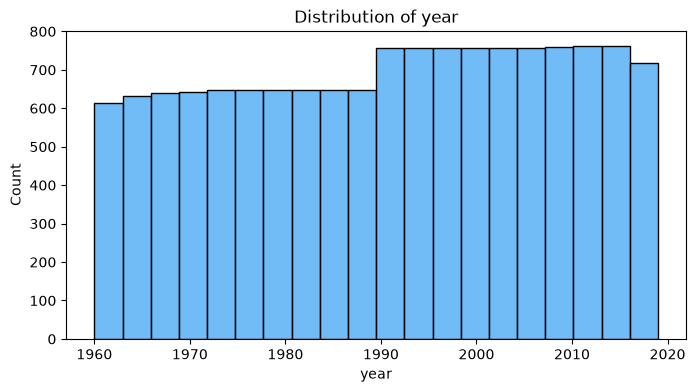

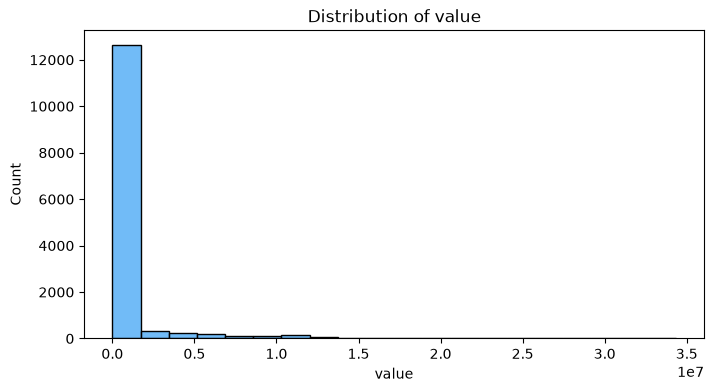

In [32]:
for column in numeric_columns:
    plt.figure(figsize=(8,4))
    
    sns.histplot(
        data=df,
        x=column,
        bins=20,
        color="#42A5F5"
        
    )
    
    plt.title(f"Distribution of {column}")
    plt.show()

## <span style="color:#42A5F5">Step 2 — Detect Outliers Visually</span>

<blockquote style="border-left: 3px solid #2196F3; padding-left: 12px; margin-left: 0;">

Box plots provide a quick visual way to identify potential outliers.

Values outside the whiskers may require further investigation.

</blockquote>

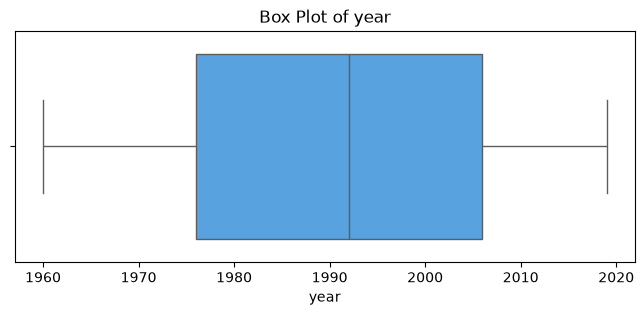

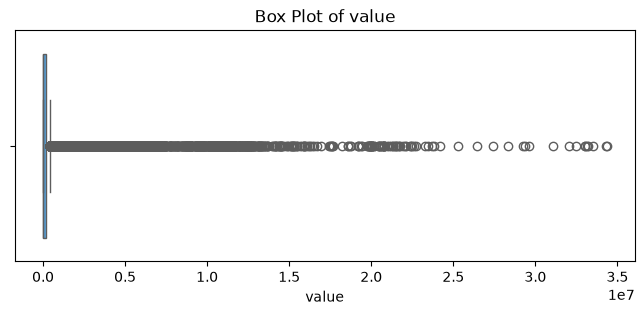

In [34]:
for column in numeric_columns:
    plt.figure(figsize=(8,3))
    
    sns.boxplot(
        data=df,
        x=column,
        color="#42A5F5"
    )
    
    plt.title(f"Box Plot of {column}")
    plt.show()

## <span style="color:#7E57C2">Step 3 — Apply IQR Outlier Detection</span>

<blockquote style="border-left: 3px solid #7E57C2; padding-left: 12px; margin-left: 0;">

We apply the IQR method to detect potential outliers in a numeric column.

After finding outliers, we investigate whether they are valid values or possible errors.

</blockquote>

In [35]:
column = "value"

Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df[column] < Q1 - 1.5 * IQR) |
    (df[column] > Q3 + 1.5 * IQR)
]

print("\033[91mNumber of detected outliers:\033[0m", len(outliers))

outliers.head()

Number of detected outliers: 2425


,country_code,country_name,year,value
100,AFE,Africa Eastern and Southern,2003,426379.996829
101,AFE,Africa Eastern and Southern,2004,457599.991269
102,AFE,Africa Eastern and Southern,2005,458459.994629
103,AFE,Africa Eastern and Southern,2006,465440.008163
104,AFE,Africa Eastern and Southern,2007,486179.996997


## <span style="color:#FFB74D">Step 4 — Analyze Categorical Variables</span>

<blockquote style="border-left: 3px solid #FFB74D; padding-left: 12px; margin-left: 0;">

Count plots show how frequently each category appears.

They help detect imbalanced categories and understand categorical distributions.

</blockquote>

In [38]:
categorical_columns = df.select_dtypes(include="object").columns

print("\033[94mCategorical Columns:\033[0m")
for col in categorical_columns:
    print("\033[92m✓\033[0m", col)

Categorical Columns:
✓ country_code
✓ country_name


C:\Users\lenovo\AppData\Local\Temp\ipykernel_27576\2682487690.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


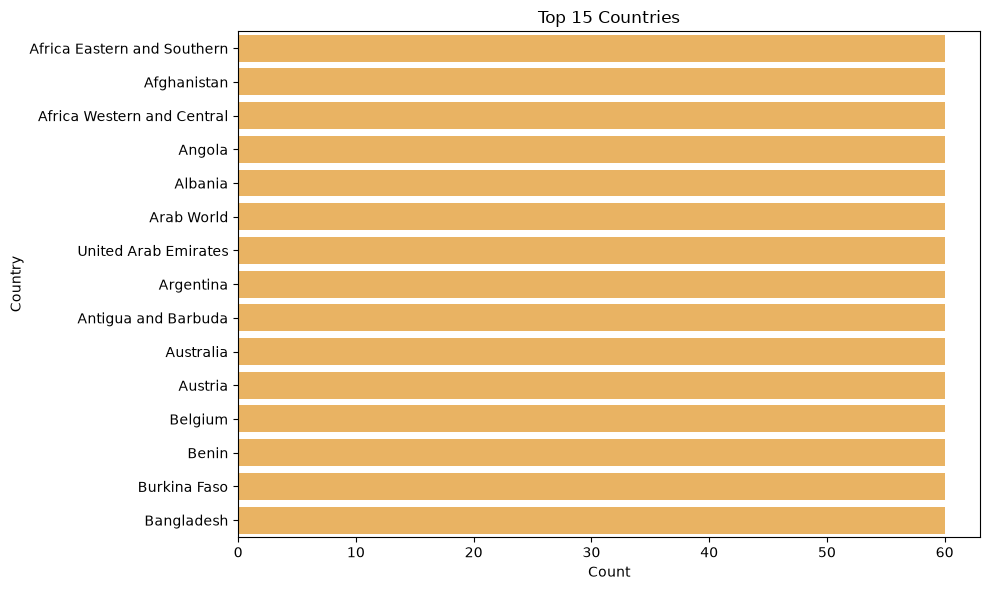

In [41]:
top_countries = df["country_name"].value_counts().head(15).index

plt.figure(figsize=(10,6))

sns.countplot(
    data=df[df["country_name"].isin(top_countries)],
    y="country_name",
    order=top_countries,
    color="#FFB74D"
)

plt.title("Top 15 Countries")
plt.xlabel("Count")
plt.ylabel("Country")

plt.tight_layout()

plt.show()

## <span style="color:#66BB6A">Step 5 — Data Insights</span>

<blockquote style="border-left: 3px solid #4CAF50; padding-left: 12px; margin-left: 0;">

After performing EDA, we can summarize:

- The overall distribution of numeric variables.
- The presence of possible outliers.
- The frequency of categorical values.
- Any patterns or unusual observations found in the dataset.

EDA helps us make better decisions before building Machine Learning models.

</blockquote>